In [132]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<span style="font-size: 40px; font-weight: bold;">Loading Dataset</span>

In [133]:
df=pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


<span style="font-size: 30px; font-weight: bold;"> Analysing the data with count and null values</span>

In [134]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [135]:
print(df.info()) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None


In [136]:
print(df.isnull().sum())

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


0 Null values in the data set

<span style="font-size: 40px; font-weight: bold;">EDA</span>

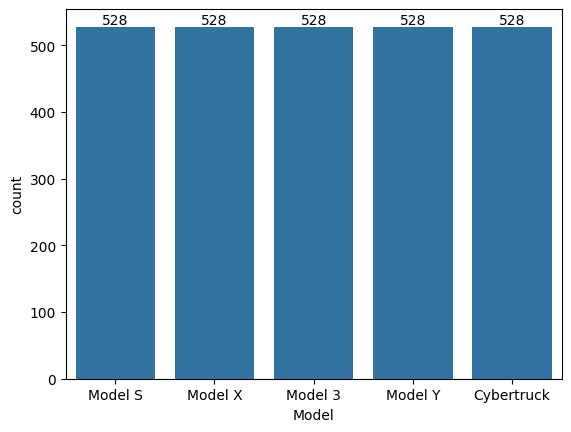

In [137]:
# Analysing the data 
ax=sns.countplot(data=df, x="Model")
ax.bar_label(ax.containers[0])
plt.show()

<span style="font-size: 30px; font-weight: bold;">Estimated Deliveries by Model name</span>

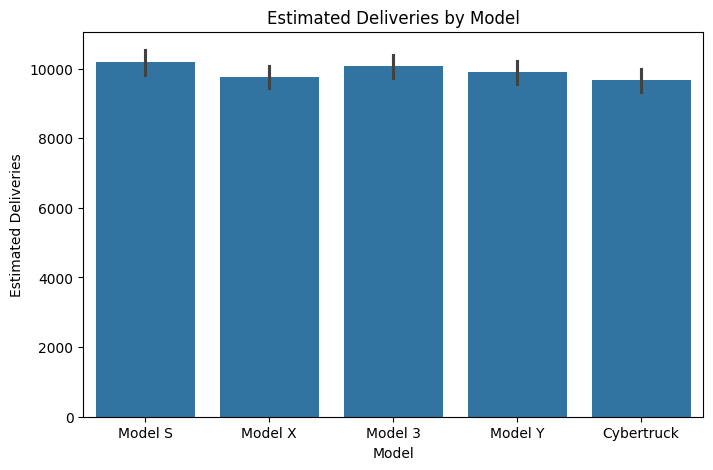

In [138]:
plt.figure(figsize=(8,5))
sns.barplot( data=df, x='Model', y='Estimated_Deliveries' )

plt.title("Estimated Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Estimated Deliveries")
plt.show()

<span style="font-size: 30px; font-weight: bold;">Deliveries by Years</span>


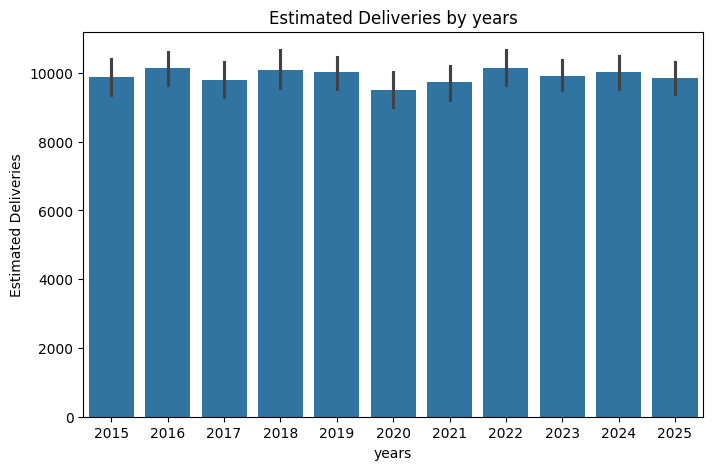

In [139]:
plt.figure(figsize=(8,5))
sns.barplot( data=df, x='Year', y='Estimated_Deliveries' )

plt.title("Estimated Deliveries by years")
plt.xlabel("years")
plt.ylabel("Estimated Deliveries")
plt.show()

<span style="font-size: 30px; font-weight: bold;">Estimated Deliveries by Regions</span>


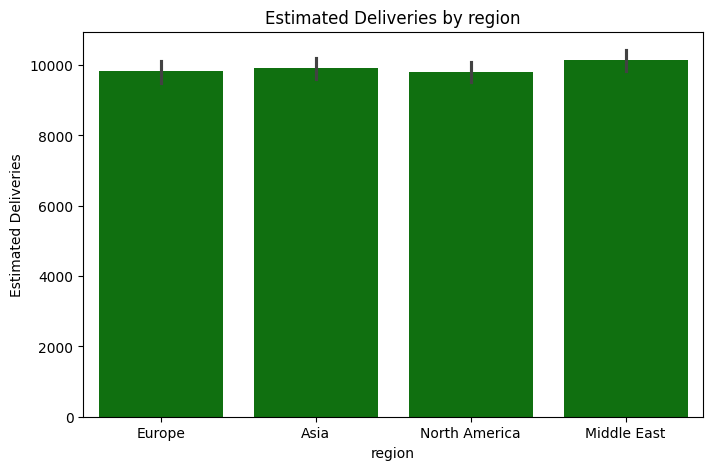

In [140]:
plt.figure(figsize=(8,5))
sns.barplot( data=df, x='Region', y='Estimated_Deliveries', color='green' )

plt.title("Estimated Deliveries by region")
plt.xlabel("region")
plt.ylabel("Estimated Deliveries")
plt.show()

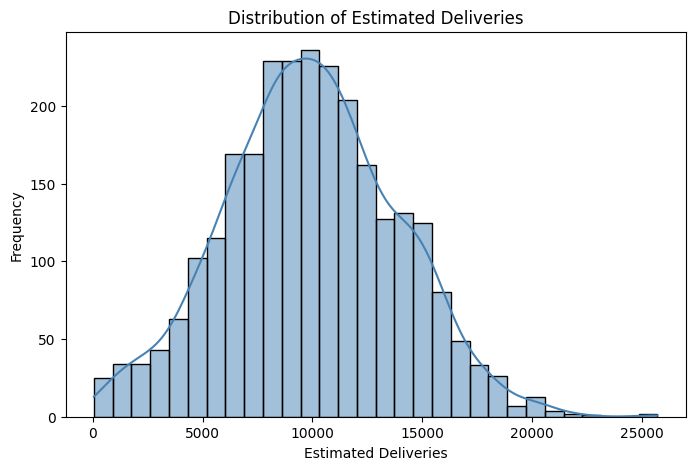

In [141]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Estimated_Deliveries'], kde=True, bins=30, color='steelblue')
plt.title('Distribution of Estimated Deliveries')
plt.xlabel('Estimated Deliveries')
plt.ylabel('Frequency')
plt.show()

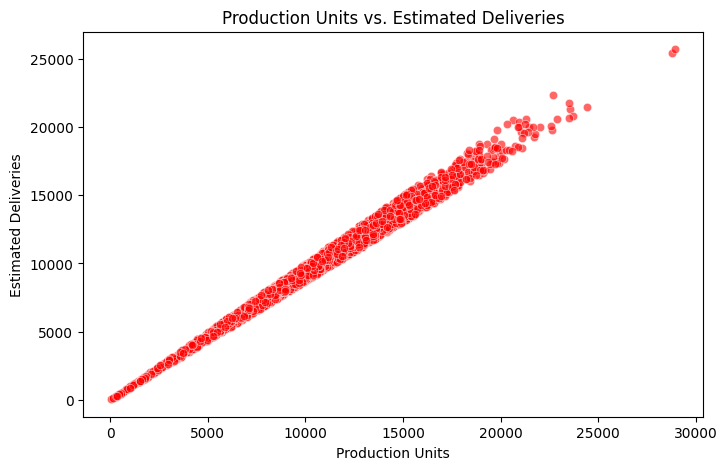

In [142]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Production_Units', y='Estimated_Deliveries', alpha=0.6, color='red')
plt.title('Production Units vs. Estimated Deliveries')
plt.xlabel('Production Units')
plt.ylabel('Estimated Deliveries')
plt.show()

<span style="font-size: 30px; font-weight: bold;"> Avg deliveries changed over Time</span>

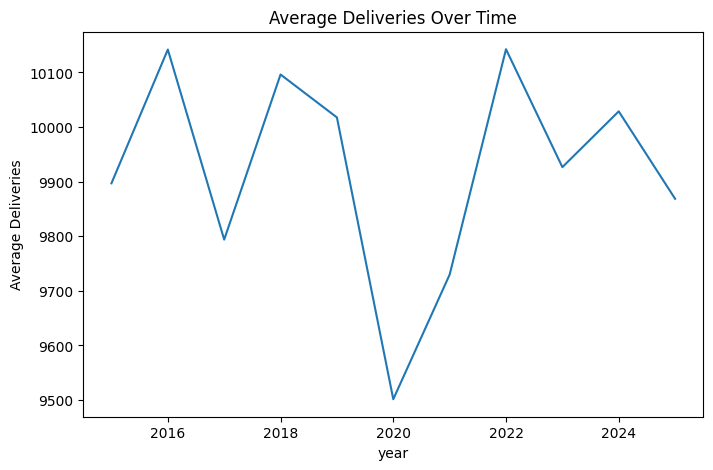

In [143]:
trend = df.groupby('Year')['Estimated_Deliveries'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    data=trend,
    x='Year',
    y='Estimated_Deliveries'
)

plt.title("Average Deliveries Over Time")
plt.xlabel("year")
plt.ylabel("Average Deliveries")

plt.show()


<span style="font-size: 30px; font-weight: bold;">correlation Heatmap</span>

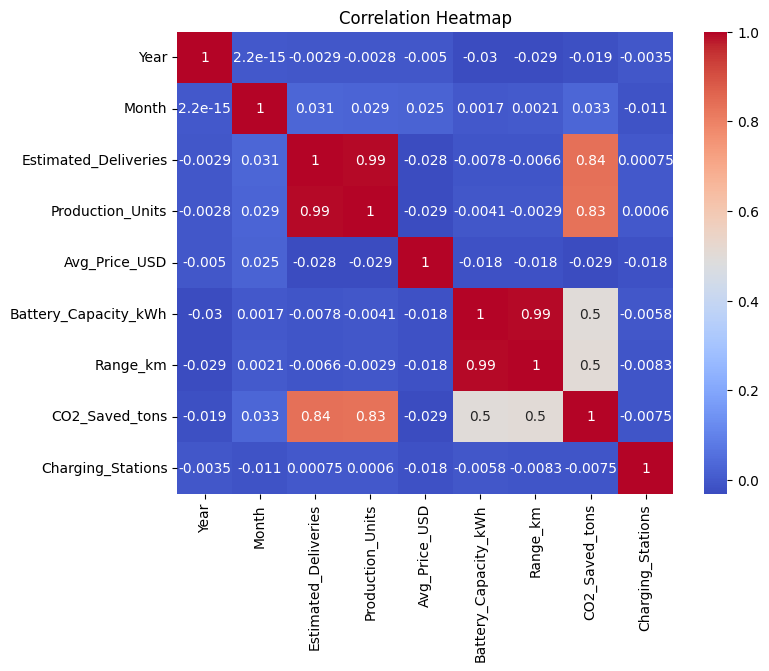

In [144]:
num_cols = df.select_dtypes(include='number')

plt.figure(figsize=(8,6))

sns.heatmap( num_cols.corr(), annot=True, cmap='coolwarm' )

plt.title("Correlation Heatmap")
plt.show()

<span style="font-size: 20px; font-weight: bold;"> In above heatmap we can see the relationships among various variables and a strong positive correlation observed between production unit and estimated deliveries . That means Higher the production higher the deliveries. </span><br>
<span style="font-size: 20px; font-weight: bold;"> As you can also see same kind of relationship betw battery capacity and range variable .</span>

<span style="font-size: 30px; font-weight: bold;"> Label Encoding </span>

In [145]:
from sklearn.preprocessing import LabelEncoder

le_model = LabelEncoder()
le_region = LabelEncoder()
le_source = LabelEncoder()

df['Model'] = le_model.fit_transform(df['Model'])
df['Region'] = le_region.fit_transform(df['Region'])
df['Source_Type'] = le_source.fit_transform(df['Source_Type'])



<span style="font-size: 30px; font-weight: bold;">Feature Engineering </span>

In [146]:
df['Deliveries_Lag1'] = df['Estimated_Deliveries'].shift(1)

df['Deliveries_Lag1'] = df['Deliveries_Lag1'].fillna(
    df['Deliveries_Lag1'].mean()
)

In [147]:
df['Rolling_Mean_3'] = ( df['Estimated_Deliveries'].shift(1).rolling(3).mean() )

df['Rolling_Mean_3'] = df['Rolling_Mean_3'].fillna(df['Rolling_Mean_3'].mean() )

In [148]:
df[['Estimated_Deliveries', 'Deliveries_Lag1','Rolling_Mean_3']].head()

,Estimated_Deliveries,Deliveries_Lag1,Rolling_Mean_3
0,17646,9924.959454,9924.988244
1,3797,17646.000000,9924.988244
2,8411,3797.000000,9924.988244
3,6555,8411.000000,9951.333333
4,12374,6555.000000,6254.333333


<span style="font-size: 20px; font-weight: bold;"> Droping the Target Feature</span>

In [149]:
y = df['Estimated_Deliveries']
X = df.drop('Estimated_Deliveries', axis=1)
X.head()

,Year,Month,Region,Model,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Deliveries_Lag1,Rolling_Mean_3
0,2023,5,1,2,17922,92874.27,120,704,1863.42,1,12207,9924.959454,9924.988244
1,2015,2,0,3,4164,62205.65,75,438,249.46,2,7640,17646.000000,9924.988244
2,2019,1,3,3,9189,117887.32,82,480,605.59,1,14071,3797.000000,9924.988244
3,2021,2,3,1,7311,89294.91,120,712,700.07,2,9333,8411.000000,9951.333333
4,2016,12,2,4,13537,114846.78,120,661,1226.88,0,8722,6555.000000,6254.333333


<span style="font-size: 20px; font-weight: bold;"> Train Test Split </span>

In [150]:
split_idx = int(0.8 * len(df))

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]



<span style="font-size: 20px; font-weight: bold;">Linear Regression </span>

In [151]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [152]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test,lr_pred)

rmse = np.sqrt( mean_squared_error(y_test,lr_pred) )

r2 = r2_score(y_test,lr_pred)

print(mae)
print(rmse)
print(r2)

310.6766709559571
376.41950683813855
0.9907639701318489


<span style="font-size: 15px; "> The dataset was split chronologically, with 80% used for training and 20% for testing to preserve temporal order and prevent data leakage. A Linear Regression model was then trained to predict Estimated_Deliveries. The model achieved an R² score of 0.9907, indicating excellent predictive performance, with low MAE and RMSE values confirming high accuracy. </span>

<span style="font-size: 20px; font-weight: bold;"> Actual Vs Predicted Graph </span>

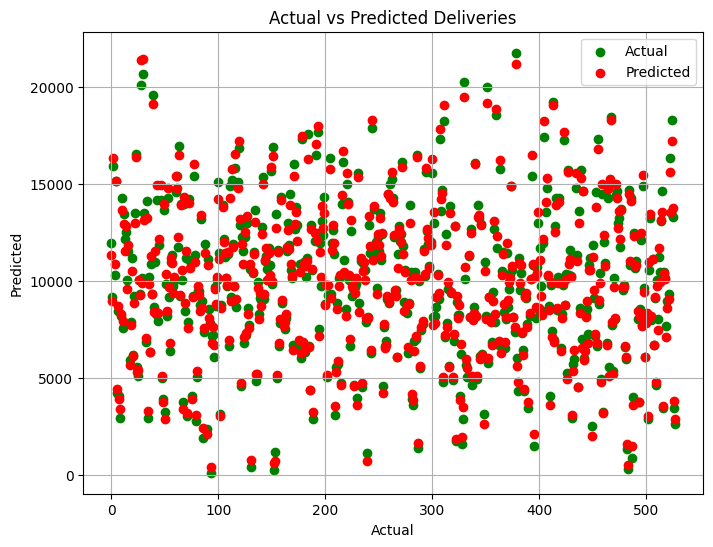

In [153]:
plt.figure(figsize=(8,6))
plt.scatter( range(len(y_test)), y_test, color='green', label='Actual' )
                 
plt.scatter( range(len(lr_pred)), lr_pred, color='red', label='Predicted' )



plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Deliveries")

plt.legend()
plt.grid(True)

plt.show()

<span style="font-size: 20px; font-weight: bold;"> Cross Validation </span>

In [160]:
from sklearn.model_selection import cross_val_score
cv_score = cross_val_score(lr,X,y,cv=5, scoring='r2')
print(cv_score)
print("Mean Accuracy= ",cv_score.mean())

[0.99063088 0.99039692 0.98927553 0.99035885 0.99076397]
Mean Accuracy=  0.9902852292380219


<span style="font-size: 30px; font-weight: bold;"> Random Forest </span>

In [155]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

params = { 'n_estimators':[50,100], 'max_depth':[5,10,None] }

rf = RandomForestRegressor( random_state=42 )

grid = GridSearchCV( rf, params, cv=5, scoring='r2' )

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, None], 'n_estimators': [50, 100]},
             scoring='r2')

In [156]:
best_rf = grid.best_estimator_

rf_pred = best_rf.predict(X_test)

print( r2_score(y_test,rf_pred))

0.9903365083225005


<span style="font-size: 15px; "> A Random Forest Regressor was tuned using GridSearchCV to find the best values of n_estimators and max_depth. The optimized model achieved an R² score above 0.99, indicating excellent prediction accuracy. While Linear Regression performed slightly better on this dataset, Random Forest also delivered highly accurate results. </span>

<span style="font-size: 20px; font-weight: bold;"> Top 5 features </span>

In [157]:
imp = pd.DataFrame({'Feature':X.columns,'Importance':best_rf.feature_importances_})

imp = imp.sort_values(by='Importance',ascending=False)

top5 = imp.head()
top5

,Feature,Importance
4,Production_Units,0.989921
8,CO2_Saved_tons,0.002121
7,Range_km,0.001296
12,Rolling_Mean_3,0.001128
5,Avg_Price_USD,0.001100


<span style="font-size: 20px; font-weight: bold;"> Visualization </span>

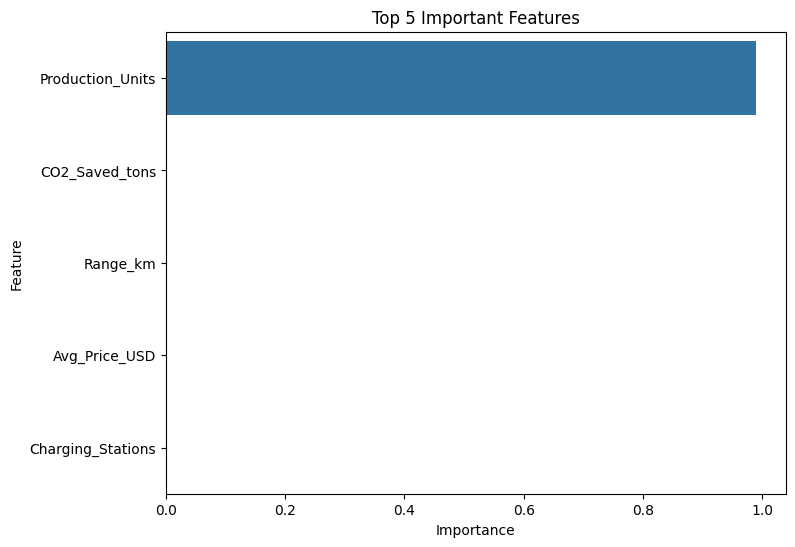

In [158]:
plt.figure(figsize=(8,6))

sns.barplot(data=top10,x='Importance',y='Feature')

plt.title("Top 5 Important Features")
plt.show()

<span style="font-size: 15px; ">As shown in the graph and data Production_unit is the most important feature for Estimated deliveries prediction.
 Other features contributed comparatively less to the prediction process.</span>

<span style="font-size: 20px; font-weight: bold;"> Comparison </span>

In [159]:
forecast = pd.DataFrame({'Actual':y_test.values,'Predicted':rf_pred})

forecast['Error_%'] = ( abs(forecast['Actual']-forecast['Predicted']) / forecast['Actual'] ) * 100

forecast.head(10)

,Actual,Predicted,Error_%
0,11974,11326.88,5.404376
1,9189,9018.00,1.860921
2,15956,16697.46,4.646904
3,10336,10913.24,5.584752
4,15152,15847.48,4.590021
5,4224,4040.08,4.354167
6,8475,8873.22,4.698761
7,4093,3832.26,6.370388
8,2972,3114.06,4.779946
9,8208,8268.88,0.741715


<span style="font-size: 15px; ">A forecast comparison table was created to evaluate the model's prediction accuracy. It displays the Actual and Predicted delivery values along with the Error Percentage for each observation. The results show that most predictions have a low error rate (generally below 7%), indicating that the model is able to predict deliveries with high accuracy and reliability.</span>

<span style="font-size: 30px; font-weight: bold;"> Conclusion </span>

<span style="font-size: 20px; ">This study developed a machine learning-based forecasting framework using Tesla delivery and production data from 2015–2025. Through data exploration, feature engineering, and predictive modeling, meaningful patterns influencing vehicle deliveries were identified. Both Linear Regression and Random Forest achieved outstanding performance, with R² scores exceeding 0.99. The results demonstrate that machine learning techniques can effectively capture delivery trends and provide accurate forecasts for future demand.</span>